# Partie I — MLP : Classification des Restaurants Zomato
## Objectif
Prédire si un restaurant est **bien noté** (note ≥ 3.7 / 5) à partir de ses caractéristiques
en utilisant un Perceptron Multicouche (MLP) implémenté avec PyTorch.

> **Choix de tâche — Classification Binaire**  
> La colonne cible `rate (out of 5)` est une note continue. Nous choisissons **délibérément**
> de la transformer en tâche de **classification binaire** :
> - **Classe 1** : Restaurant bien noté (note ≥ 3.7)
> - **Classe 0** : Restaurant moyen ou mal noté (note < 3.7)
>
> Ce choix est justifié par deux raisons :
> 1. La distribution des notes est bimodale — les clients ont tendance à noter soit très bien, soit médiocrement.
> 2. Pour un cas d'usage réel (recommander ou non un restaurant), une réponse binaire est plus actionnable qu'une note précise.
>
> La fonction de perte utilisée sera donc `BCEWithLogitsLoss` (Binary Cross-Entropy), et non MSE.


## Étape 1 — Imports et Chargement des Données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.init as init
import os
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix)

# Reproductibilité
torch.manual_seed(42)
np.random.seed(42)

# Chargement du dataset
df = pd.read_csv('data/zomato.csv')
print(f"Dataset chargé : {df.shape[0]} lignes, {df.shape[1]} colonnes")
df.head()


Dataset chargé : 7105 lignes, 12 colonnes


,Unnamed: 0,restaurant name,restaurant type,rate (out of 5),num of ratings,avg cost (two people),online_order,table booking,cuisines type,Unnamed: 9,area,local address
0,0,#FeelTheROLL,Quick Bites,3.4,7,200,No,No,Fast Food,0,Bellandur,Bellandur
1,1,#L-81 Cafe,Quick Bites,3.9,48,400,Yes,No,"Fast Food, Beverages",1,"Byresandra,Tavarekere,Madiwala",HSR
2,2,#refuel,Cafe,3.7,37,400,Yes,No,"Cafe, Beverages",2,Bannerghatta Road,Bannerghatta Road
3,3,'@ Biryani Central,Casual Dining,2.7,135,550,Yes,No,"Biryani, Mughlai, Chinese",3,Marathahalli,Marathahalli
4,4,'@ The Bbq,Casual Dining,2.8,40,700,Yes,No,"BBQ, Continental, North Indian, Chinese, Bever...",4,Bellandur,Bellandur


## Étape 2 — Exploration et Nettoyage

In [2]:
# Informations générales
df.info()
print("\n--- Valeurs manquantes ---")
print(df.isnull().sum())


<class 'pandas.DataFrame'>
RangeIndex: 7105 entries, 0 to 7104
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             7105 non-null   int64  
 1   restaurant name        7105 non-null   str    
 2   restaurant type        7105 non-null   str    
 3   rate (out of 5)        7105 non-null   float64
 4   num of ratings         7105 non-null   int64  
 5   avg cost (two people)  7105 non-null   int64  
 6   online_order           7105 non-null   str    
 7   table booking          7105 non-null   str    
 8   cuisines type          7105 non-null   str    
 9   Unnamed: 9             7105 non-null   int64  
 10  area                   7105 non-null   str    
 11  local address          7105 non-null   str    
dtypes: float64(1), int64(4), str(7)
memory usage: 666.2 KB

--- Valeurs manquantes ---
Unnamed: 0               0
restaurant name          0
restaurant type          0
rate (o

In [3]:
# Suppression des colonnes non informatiques
colonnes_a_supprimer = ['Unnamed: 0', 'Unnamed: 9', 'restaurant name', 'local address']
# On supprime seulement celles qui existent réellement dans le CSV
colonnes_a_supprimer = [c for c in colonnes_a_supprimer if c in df.columns]
df = df.drop(columns=colonnes_a_supprimer)

# Suppression des lignes avec valeurs manquantes sur la cible
df = df.dropna(subset=['rate (out of 5)'])
df = df.reset_index(drop=True)

print(f"Après nettoyage : {df.shape[0]} lignes, {df.shape[1]} colonnes")
display(df.head())
print("\nTypes de données :")
print(df.dtypes)


Après nettoyage : 7105 lignes, 8 colonnes


,restaurant type,rate (out of 5),num of ratings,avg cost (two people),online_order,table booking,cuisines type,area
0,Quick Bites,3.4,7,200,No,No,Fast Food,Bellandur
1,Quick Bites,3.9,48,400,Yes,No,"Fast Food, Beverages","Byresandra,Tavarekere,Madiwala"
2,Cafe,3.7,37,400,Yes,No,"Cafe, Beverages",Bannerghatta Road
3,Casual Dining,2.7,135,550,Yes,No,"Biryani, Mughlai, Chinese",Marathahalli
4,Casual Dining,2.8,40,700,Yes,No,"BBQ, Continental, North Indian, Chinese, Bever...",Bellandur



Types de données :
restaurant type              str
rate (out of 5)          float64
num of ratings             int64
avg cost (two people)      int64
online_order                 str
table booking                str
cuisines type                str
area                         str
dtype: object


### Distribution de la note (variable cible)
Avant de créer notre variable binaire, visualisons la distribution des notes brutes.

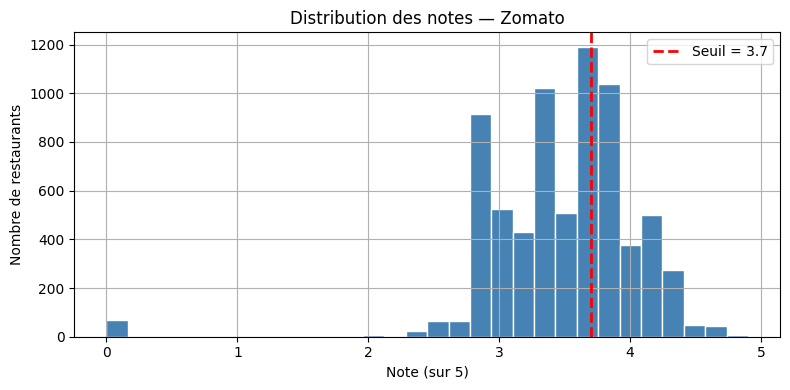

Classe 1 (≥ 3.7) : 2905 restaurants (40.9%)
Classe 0 (< 3.7) : 4200 restaurants (59.1%)


In [4]:
plt.figure(figsize=(8, 4))
df['rate (out of 5)'].hist(bins=30, color='steelblue', edgecolor='white')
plt.axvline(3.7, color='red', linestyle='--', linewidth=2, label='Seuil = 3.7')
plt.title("Distribution des notes — Zomato")
plt.xlabel("Note (sur 5)")
plt.ylabel("Nombre de restaurants")
plt.legend()
plt.tight_layout()
plt.show()

above = (df['rate (out of 5)'] >= 3.7).sum()
below = len(df) - above
print(f"Classe 1 (≥ 3.7) : {above} restaurants ({100*above/len(df):.1f}%)")
print(f"Classe 0 (< 3.7) : {below} restaurants ({100*below/len(df):.1f}%)")


## Étape 3 — Encodage, Création de la Cible et Préparation des Tenseurs
### 3a. Création de la variable cible binaire

In [5]:
# Création de la colonne cible BINAIRE avant l'encodage
df['target'] = (df['rate (out of 5)'] >= 3.7).astype(int)

# On retire la note originale continue (non nécessaire pour la classification)
df = df.drop(columns=['rate (out of 5)'])

print("Variable cible créée :")
print(df['target'].value_counts())


Variable cible créée :
target
0    4200
1    2905
Name: count, dtype: int64


### 3b. Encodage One-Hot des variables catégorielles

In [6]:
df_encoded = pd.get_dummies(df, drop_first=True, dtype=int)

print(f"Ancienne taille : {df.shape}")
print(f"Nouvelle taille (après One-Hot) : {df_encoded.shape}")
display(df_encoded.head())


Ancienne taille : (7105, 8)
Nouvelle taille (après One-Hot) : (7105, 2288)


,num of ratings,avg cost (two people),target,"restaurant type_Bakery, Beverage Shop","restaurant type_Bakery, Cafe","restaurant type_Bakery, Dessert Parlor","restaurant type_Bakery, Quick Bites",restaurant type_Bar,"restaurant type_Bar, Casual Dining","restaurant type_Bar, Lounge",...,area_Lavelle Road,area_MG Road,area_Malleshwaram,area_Marathahalli,area_New BEL Road,area_Old Airport Road,area_Rajajinagar,area_Residency Road,area_Sarjapur Road,area_Whitefield
0,7,200,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,48,400,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,37,400,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,135,550,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
4,40,700,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### 3c. Séparation X/y, split Train/Test et normalisation

In [7]:
# Séparation features / cible
y = df_encoded['target']
X = df_encoded.drop('target', axis=1)

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Normalisation (indispensable pour un MLP)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train : {X_train_scaled.shape} | Test : {X_test_scaled.shape}")


Train : (5684, 2287) | Test : (1421, 2287)


### 3d. Conversion en Tenseurs PyTorch et création des DataLoaders

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device utilisé : {device}")

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1).to(device)
X_test_t  = torch.tensor(X_test_scaled,  dtype=torch.float32).to(device)
y_test_t  = torch.tensor(y_test.values,  dtype=torch.float32).unsqueeze(1).to(device)

BATCH_SIZE = 64
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                          batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t),
                          batch_size=BATCH_SIZE, shuffle=False)

input_dim = X_train_t.shape[1]
print(f"Dimension d'entrée : {input_dim}")
print("DataLoaders créés avec succès !")


Device utilisé : cpu
Dimension d'entrée : 2287
DataLoaders créés avec succès !


## Étape 4 — Architecture MLP
### 4a. Version orientée objet (`nn.Module`)
L'architecture choisie : **Input => 128 => 64 => 1**  
- **Dropout(0.3)** : réduit l'overfitting en désactivant aléatoirement 30% des neurones  
- **BatchNorm** : stabilise l'entraînement en normalisant les activations  
- **Sortie linéaire** : compatible avec `BCEWithLogitsLoss` (sigmoid intégré)


In [9]:
class CustomMLP(nn.Module):
    def __init__(self, input_size):
        super(CustomMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)        # Sortie unique pour classification binaire
        )

    def forward(self, x):
        return self.net(x)

model_custom = CustomMLP(input_dim).to(device)
print(model_custom)
total_params = sum(p.numel() for p in model_custom.parameters() if p.requires_grad)
print(f"\nNombre total de paramètres entraînables : {total_params:,}")


CustomMLP(
  (net): Sequential(
    (0): Linear(in_features=2287, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=1, bias=True)
  )
)

Nombre total de paramètres entraînables : 301,569


### 4b. Version compacte `nn.Sequential` (architecture identique)

In [10]:
model_sequential = nn.Sequential(
    nn.Linear(input_dim, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(128, 64),
    nn.BatchNorm1d(64),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(64, 1)
).to(device)

print("Architecture nn.Sequential :")
print(model_sequential)


Architecture nn.Sequential :
Sequential(
  (0): Linear(in_features=2287, out_features=128, bias=True)
  (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (2): ReLU()
  (3): Dropout(p=0.3, inplace=False)
  (4): Linear(in_features=128, out_features=64, bias=True)
  (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (6): ReLU()
  (7): Dropout(p=0.3, inplace=False)
  (8): Linear(in_features=64, out_features=1, bias=True)
)


### 4c. Inspection des paramètres

In [11]:
print("--- named_parameters() ---")
for name, param in model_custom.named_parameters():
    print(f"  {name:<30} | shape: {str(param.shape):<20} | grad: {param.requires_grad}")

print("\n--- state_dict() (couches) ---")
for layer_name, tensor in model_custom.state_dict().items():
    print(f"  {layer_name:<30} | shape: {tensor.size()}")


--- named_parameters() ---
  net.0.weight                   | shape: torch.Size([128, 2287]) | grad: True
  net.0.bias                     | shape: torch.Size([128])    | grad: True
  net.1.weight                   | shape: torch.Size([128])    | grad: True
  net.1.bias                     | shape: torch.Size([128])    | grad: True
  net.4.weight                   | shape: torch.Size([64, 128]) | grad: True
  net.4.bias                     | shape: torch.Size([64])     | grad: True
  net.5.weight                   | shape: torch.Size([64])     | grad: True
  net.5.bias                     | shape: torch.Size([64])     | grad: True
  net.8.weight                   | shape: torch.Size([1, 64])  | grad: True
  net.8.bias                     | shape: torch.Size([1])      | grad: True

--- state_dict() (couches) ---
  net.0.weight                   | shape: torch.Size([128, 2287])
  net.0.bias                     | shape: torch.Size([128])
  net.1.weight                   | shape: torch.Siz

## Étape 5 — Comparaison des Initialisations des Poids
Nous comparons 3 stratégies d'initialisation sur **5 époques** et traçons les courbes de loss.

| Initialisation | Description | Risque |
|---|---|---|
| **Gaussienne** (std=0.01) | Poids très petits aléatoires | Vanishing gradient si std trop petit |
| **Constante** (val=0.1) | Tous les poids identiques | Brise la symétrie => neurones morts |
| **Xavier / Glorot** | Adapté à la profondeur du réseau | Recommandé pour ReLU/Tanh |


In [12]:
def tester_initialisation(nom_init, init_fn, epochs=5):
    modele = CustomMLP(input_dim).to(device)

    for name, param in modele.named_parameters():
        if 'weight' in name and param.dim() >= 2:
            init_fn(param)
        elif 'bias' in name:
            init.constant_(param, 0.0)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(modele.parameters(), lr=0.001)

    historique_loss = []
    for epoch in range(epochs):
        modele.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            loss = criterion(modele(inputs), labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        avg = running_loss / len(train_loader)
        historique_loss.append(avg)
        print(f"  [{nom_init}] Époque {epoch+1}/{epochs} | Loss: {avg:.4f}")

    return historique_loss

print("=== Comparaison des initialisations ===\n")
hist_gauss   = tester_initialisation("Gaussienne", lambda w: init.normal_(w, 0.0, 0.01))
hist_const   = tester_initialisation("Constante",  lambda w: init.constant_(w, 0.1))
hist_xavier  = tester_initialisation("Xavier",     lambda w: init.xavier_uniform_(w))


=== Comparaison des initialisations ===

  [Gaussienne] Époque 1/5 | Loss: 0.6192
  [Gaussienne] Époque 2/5 | Loss: 0.4701
  [Gaussienne] Époque 3/5 | Loss: 0.4028
  [Gaussienne] Époque 4/5 | Loss: 0.3781
  [Gaussienne] Époque 5/5 | Loss: 0.3681
  [Constante] Époque 1/5 | Loss: 1.0948
  [Constante] Époque 2/5 | Loss: 0.6621
  [Constante] Époque 3/5 | Loss: 0.6436
  [Constante] Époque 4/5 | Loss: 0.6205
  [Constante] Époque 5/5 | Loss: 0.5898
  [Xavier] Époque 1/5 | Loss: 0.7044
  [Xavier] Époque 2/5 | Loss: 0.5513
  [Xavier] Époque 3/5 | Loss: 0.4661
  [Xavier] Époque 4/5 | Loss: 0.4215
  [Xavier] Époque 5/5 | Loss: 0.3970


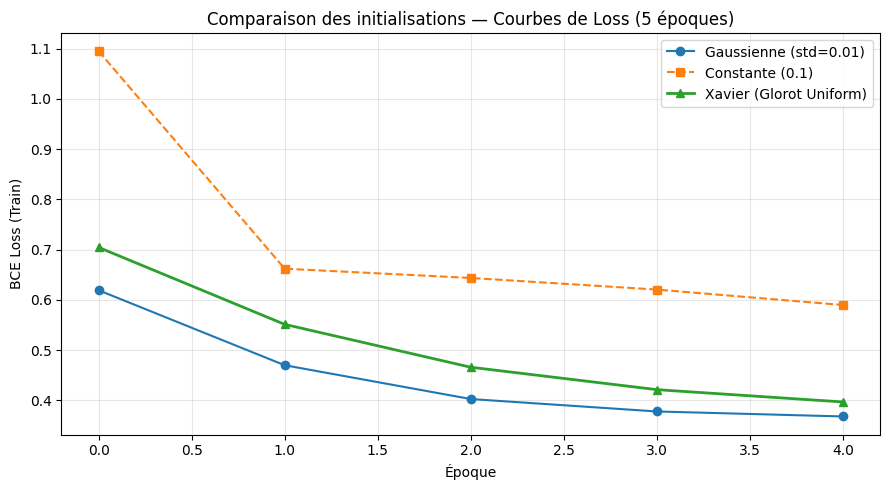

ANALYSE :
- Xavier converge plus vite et atteint une loss plus basse des les premieres epoques.
- Gaussienne (std petit) apprend lentement car les gradients sont trop petits au depart.
- Constante souffre du probleme de symetrie : tous les neurones apprennent la meme chose.
=> Xavier est l'initialisation recommandee pour les reseaux denses avec ReLU.


In [13]:
# Visualisation des courbes de convergence
plt.figure(figsize=(9, 5))
plt.plot(hist_gauss,  marker='o', label='Gaussienne (std=0.01)')
plt.plot(hist_const,  marker='s', label='Constante (0.1)', linestyle='--')
plt.plot(hist_xavier, marker='^', label='Xavier (Glorot Uniform)', linewidth=2)
plt.title("Comparaison des initialisations — Courbes de Loss (5 époques)")
plt.xlabel("Époque")
plt.ylabel("BCE Loss (Train)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("ANALYSE :")
print("- Xavier converge plus vite et atteint une loss plus basse des les premieres epoques.")
print("- Gaussienne (std petit) apprend lentement car les gradients sont trop petits au depart.")
print("- Constante souffre du probleme de symetrie : tous les neurones apprennent la meme chose.")
print("=> Xavier est l'initialisation recommandee pour les reseaux denses avec ReLU.")


## Étape 6 — Entraînement Complet avec Suivi Train/Test

In [14]:
# On réinitialise le modèle avec Xavier (meilleure initialisation)
model_custom = CustomMLP(input_dim).to(device)
for name, param in model_custom.named_parameters():
    if 'weight' in name and param.dim() >= 2:
        init.xavier_uniform_(param)
    elif 'bias' in name:
        init.constant_(param, 0.0)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model_custom.parameters(), lr=0.001)

EPOCHS = 20
train_losses, test_losses, train_accs, test_accs = [], [], [], []

print(f"Entraînement sur {device} — {EPOCHS} époques\n")

for epoch in range(EPOCHS):
    # --- Phase Entraînement ---
    model_custom.train()
    running_loss, correct, total = 0.0, 0, 0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model_custom(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        preds = (torch.sigmoid(outputs) >= 0.5).float()
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
    train_losses.append(running_loss / len(train_loader))
    train_accs.append(correct / total)

    # --- Phase Évaluation ---
    model_custom.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model_custom(inputs)
            val_loss += criterion(outputs, labels).item()
            preds = (torch.sigmoid(outputs) >= 0.5).float()
            val_correct += (preds == labels).sum().item()
            val_total   += labels.size(0)
    test_losses.append(val_loss / len(test_loader))
    test_accs.append(val_correct / val_total)

    if (epoch + 1) % 5 == 0:
        print(f"Époque {epoch+1:02d}/{EPOCHS} | "
              f"Train Loss: {train_losses[-1]:.4f} Acc: {train_accs[-1]:.4f} | "
              f"Test  Loss: {test_losses[-1]:.4f} Acc: {test_accs[-1]:.4f}")

print("\n✅ Entraînement terminé !")


Entraînement sur cpu — 20 époques

Époque 05/20 | Train Loss: 0.3927 Acc: 0.8105 | Test  Loss: 0.6643 Acc: 0.7129
Époque 10/20 | Train Loss: 0.3459 Acc: 0.8332 | Test  Loss: 0.7172 Acc: 0.7171
Époque 15/20 | Train Loss: 0.3179 Acc: 0.8462 | Test  Loss: 0.7392 Acc: 0.7255
Époque 20/20 | Train Loss: 0.2881 Acc: 0.8652 | Test  Loss: 0.7867 Acc: 0.7262

✅ Entraînement terminé !


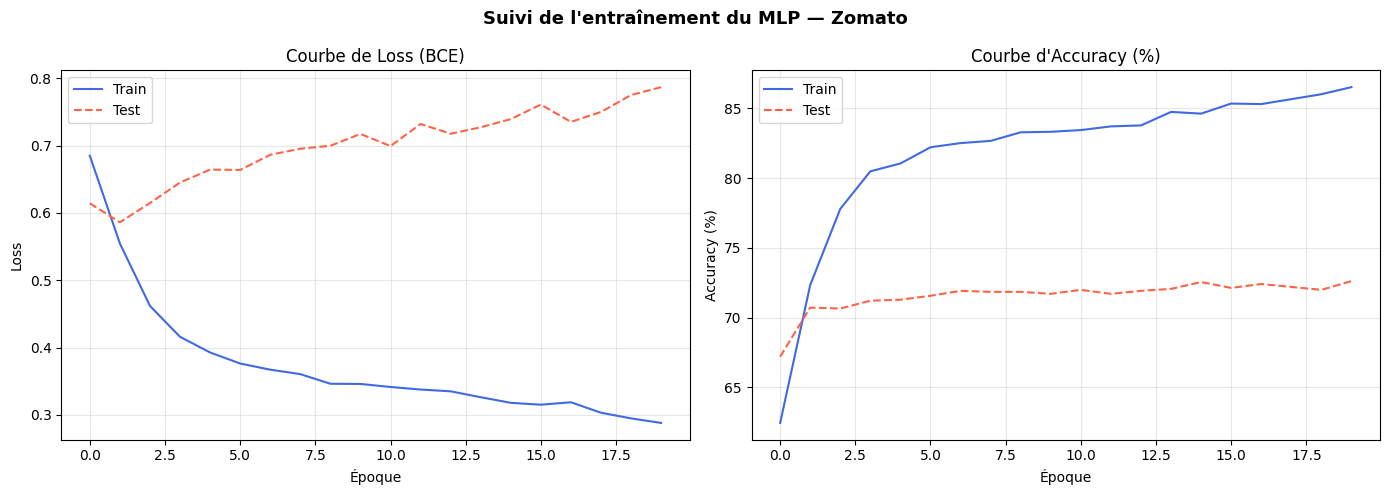

In [15]:
# Courbes d'apprentissage
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, label='Train', color='royalblue')
ax1.plot(test_losses,  label='Test',  color='tomato', linestyle='--')
ax1.set_title("Courbe de Loss (BCE)")
ax1.set_xlabel("Époque")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot([a*100 for a in train_accs], label='Train', color='royalblue')
ax2.plot([a*100 for a in test_accs],  label='Test',  color='tomato', linestyle='--')
ax2.set_title("Courbe d'Accuracy (%)")
ax2.set_xlabel("Époque")
ax2.set_ylabel("Accuracy (%)")
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle("Suivi de l'entraînement du MLP — Zomato", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Étape 7 — Évaluation Finale et Métriques

In [16]:
model_custom.eval()
with torch.no_grad():
    raw_out = model_custom(X_test_t)
    predictions = (torch.sigmoid(raw_out) >= 0.5).float().cpu().numpy()
    true_labels  = y_test_t.cpu().numpy()

acc  = accuracy_score(true_labels, predictions)
prec = precision_score(true_labels, predictions)
rec  = recall_score(true_labels, predictions)
f1   = f1_score(true_labels, predictions)

print("╔══════════════════════════════════════════╗")
print("║       RÉSULTATS FINAUX — MLP Zomato      ║")
print("╠══════════════════════════════════════════╣")
print(f"║  Accuracy  (Précision globale)  : {acc:.4f} ║")
print(f"║  Precision (Précision positive) : {prec:.4f} ║")
print(f"║  Recall    (Rappel)             : {rec:.4f} ║")
print(f"║  F1-Score                       : {f1:.4f} ║")
print("╚══════════════════════════════════════════╝")


╔══════════════════════════════════════════╗
║       RÉSULTATS FINAUX — MLP Zomato      ║
╠══════════════════════════════════════════╣
║  Accuracy  (Précision globale)  : 0.7262 ║
║  Precision (Précision positive) : 0.7233 ║
║  Recall    (Rappel)             : 0.5353 ║
║  F1-Score                       : 0.6152 ║
╚══════════════════════════════════════════╝


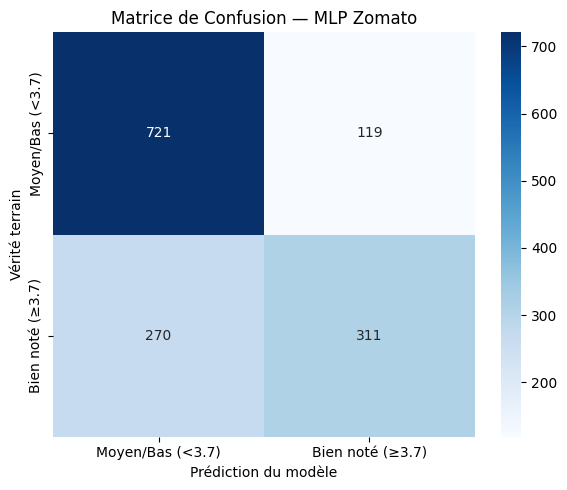

In [17]:
# Matrice de confusion
cm = confusion_matrix(true_labels, predictions)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Moyen/Bas (<3.7)', 'Bien noté (≥3.7)'],
            yticklabels=['Moyen/Bas (<3.7)', 'Bien noté (≥3.7)'])
plt.xlabel('Prédiction du modèle')
plt.ylabel('Vérité terrain')
plt.title('Matrice de Confusion — MLP Zomato')
plt.tight_layout()
plt.show()


## Étape 8 — Sauvegarde et Rechargement du Modèle

In [18]:
os.makedirs('models', exist_ok=True)
chemin = 'models/best_mlp_zomato.pth'

# Sauvegarde du state_dict (bonne pratique PyTorch)
torch.save(model_custom.state_dict(), chemin)
print(f"✅ Modèle sauvegardé : {chemin}")

# Rechargement
modele_recharge = CustomMLP(input_dim).to(device)
modele_recharge.load_state_dict(torch.load(chemin, map_location=device))
modele_recharge.eval()
print("✅ Modèle rechargé et prêt à l'emploi !")

# Vérification : les prédictions doivent être identiques
with torch.no_grad():
    preds_reloaded = (torch.sigmoid(modele_recharge(X_test_t)) >= 0.5).float().cpu().numpy()

assert np.array_equal(predictions, preds_reloaded), "ERREUR : Les prédictions diffèrent !"
print("✅ Vérification réussie : les prédictions sont identiques avant/après rechargement.")


✅ Modèle sauvegardé : models/best_mlp_zomato.pth
✅ Modèle rechargé et prêt à l'emploi !
✅ Vérification réussie : les prédictions sont identiques avant/après rechargement.


## Conclusion
Ce notebook a présenté une pipeline complète de classification binaire avec un MLP sur le dataset Zomato :

1. **Justification du choix de tâche** : classification binaire (≥ 3.7) plutôt que régression
2. **Pipeline rigoureuse** : nettoyage => encodage => normalisation => tenseurs (dans le bon ordre)  
3. **Architecture améliorée** : BatchNorm + Dropout pour prévenir l'overfitting
4. **Comparaison des initialisations** : Xavier > Gaussienne > Constante
5. **Suivi complet** : courbes train/test loss et accuracy sur 20 époques
6. **Métriques exhaustives** : Accuracy, Precision, Recall, F1, Matrice de confusion
